# 08. 그래프
## sns.scatterplot - 두 변수간의 관계를 표현


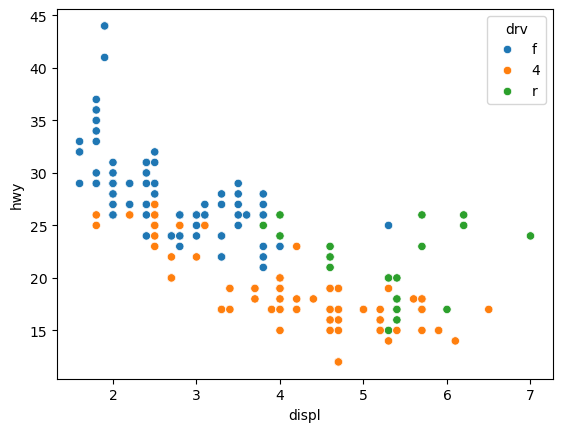

In [11]:
import pandas as pd
import seaborn as sns
mpg = pd.read_csv('mpg.csv')

sns.scatterplot(data=mpg, x='displ',y='hwy',hue='drv'); # 배기량과 고속연비간의 관계


[(1.0, 500000.0), (1.0, 10000.0)]

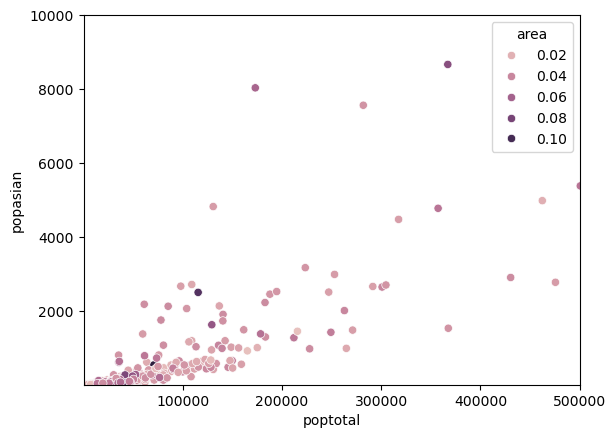

In [ ]:
# 혼자서 해보기
# q1. cty와 hwy간에 어떤 관계가 있는지 알아보자
sns.scatterplot(data=mpg, x='cty', y='hwy',hue='displ')

# q2. midwest.csv에서 전체인구와 아시아인 인구간에 어떤 관계가 있는지 알아보자. x축은 전체인구 ,y축은 아시아인구로 산점도 그래프 만들어본다
md = pd.read_csv('midwest.csv')
sns.scatterplot(data=md, x='poptotal', y='popasian',hue='area').set(xlim=[1,500_000],ylim=[1,10_000])

## sns.barplot - 집단간 비교

<Axes: xlabel='drv', ylabel='mean_hwy'>

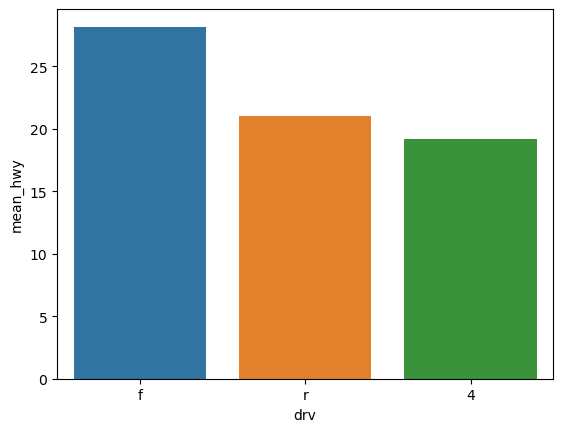

In [21]:
df_mpg = mpg.groupby('drv',as_index=False).agg(mean_hwy = ('hwy','mean')).sort_values('mean_hwy',ascending=False)
sns.barplot(data=df_mpg, x='drv',y='mean_hwy',hue='drv')


<Axes: xlabel='drv', ylabel='count'>

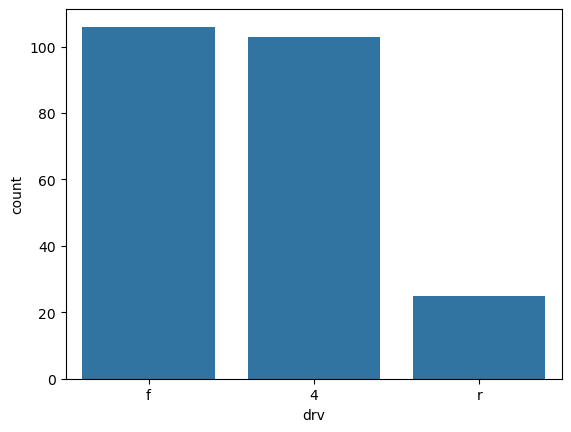

In [ ]:
# 빈도 그래프 (개수)
df_mpg = mpg.groupby('drv',as_index=False).agg(counting = ('drv','count')).sort_values('counting',ascending=False)
sns.barplot(data=df_mpg, x='drv',y='counting')

# sns.countplot()이 더 간편하다
sns.countplot(data=mpg, x='drv',order=['4','f','r'])

#빈도가 높은 순으로 표현하려면 order에 수식을 넣으면 된다
sns.countplot(data=mpg, x='drv',order=mpg['drv'].value_counts().index)

<Axes: xlabel='category', ylabel='n'>

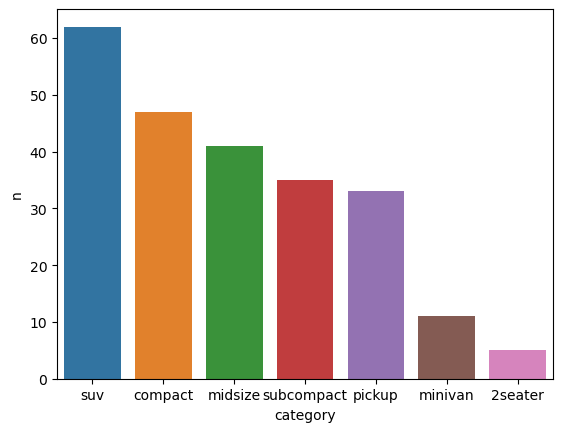

In [ ]:
# 혼자서 해보기
# #q1. 'suv'차종을 대상으로 cty 평균이 높은 회사 5곳을 막대그래프로 표현
suv_five = mpg.query('category == "suv"').groupby('manufacturer').agg(cty_mean = ('cty','mean')).sort_values('cty_mean',ascending=False).head(5)
sns.barplot(data=suv_five, x='manufacturer', y='cty_mean',hue='manufacturer')

#q2. 자동차중 어떤 category가 많은지 알아보려함 .sns.barplot()을 이용해 빈도를 표현한 막대그래프를 만든다
category_mpg = mpg.groupby('category').agg(n=('category','count')).sort_values('n',ascending=False)
sns.barplot(data=category_mpg, x='category', y='n', hue='category')


## lineplot - 시계열 그래프

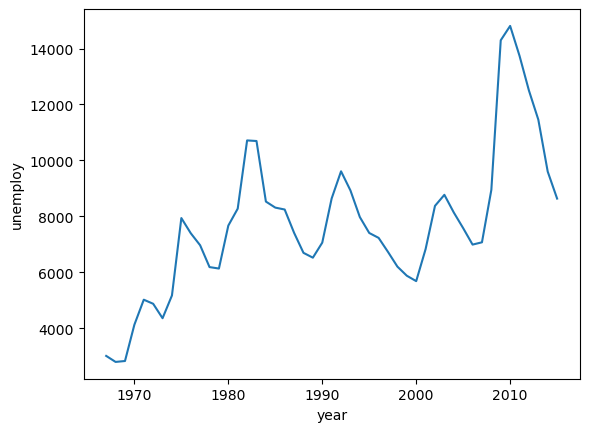

In [47]:
economics = pd.read_csv('economics.csv')

economics['date2'] = pd.to_datetime(economics['date'])
economics['year'] = economics['date2'].dt.year

sns.lineplot(data=economics, x='year',y='unemploy',errorbar = None); # 신뢰구간 표시를 끄려면 errorbar = None을 써준다

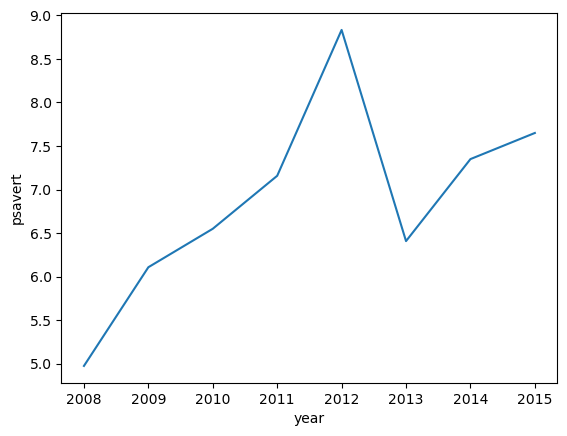

In [ ]:
# 혼자서 해보기
# q1. psavert(개인저축률) 연도별 개인저축률 변화를 시계열그래프로 만들어보라
sns.lineplot(data=economics, x='year', y='psavert',errorbar=None)
# q2. 2014년 월별 psavert의 변화를 나타낸 시계열 그래프를 만들어보라
economics['month'] = economics['date2'].dt.month

q2 = economics.query('year == 2014')
sns.lineplot(data=q2, x='month',y='psavert',errorbar=None);

# 2008년이후 미국 개인저축률이 어떻게 변했을까?
q3 = economics.query('year >= 2008')
sns.lineplot(data=q3, x='year', y='psavert',errorbar=None);


## sns.boxplot() - 집단간 분포차이

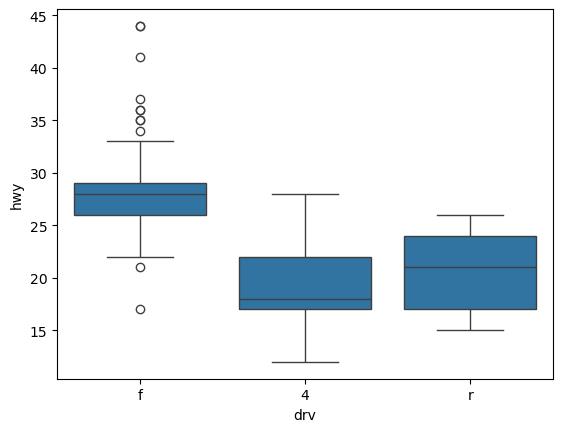

In [ ]:
#sns.boxplot(data=mpg, x='category',y='hwy');
sns.boxplot(data=mpg, x='drv',y='hwy');

<Axes: xlabel='category', ylabel='cty'>

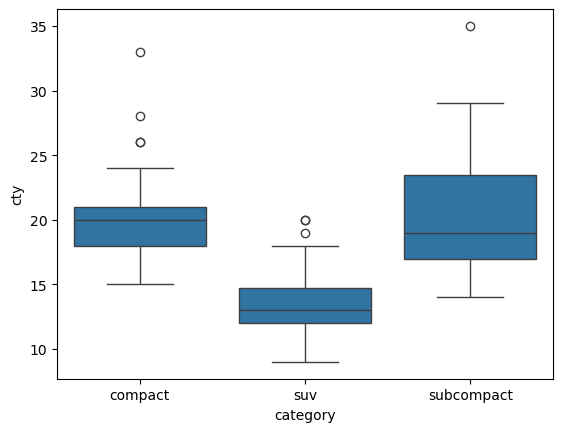

In [ ]:
# 혼자서 해보기
# q1. 자동차 종류에 따른 도시연비가 어떻게 다른지 비교하고 싶다
q1 = mpg.query("category in ['compact','subcompact','suv']")

sns.boxplot(data=q1, x='category',y='cty')